<a href="https://colab.research.google.com/github/lehuuphucwork-oss/Baitap_2/blob/HW03/NNFL_HW03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers

# For result repeatable
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# 1/ Date Setup

#   Load MNIST dataset
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

# Preprocess the data
# Reshape
train_images = train_images.reshape((60000, 28 * 28))
test_images  = test_images.reshape((10000, 28 * 28))
# Normalize
train_images = train_images.astype("float32") / 255
test_images  = test_images.astype("float32") / 255
# Encode labels
train_labels = keras.utils.to_categorical(train_labels)
test_labels  = keras.utils.to_categorical(test_labels)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# 2/ Build Two Different Models

# Model A - Shallow
  # o Hidden Layers: 1
  # o Neurons: 128
  # o Activation: relu
model_a = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(28 * 28,)),
    layers.Dense(10, activation="softmax")
])

model_a.compile(optimizer="rmsprop",
                loss="categorical_crossentropy",
                metrics=["accuracy"])

# Model B - Deep
  # o Hidden Layers: 4 (Stacked)
  # o Neurons: 𝟔𝟔𝟔𝟔 → 𝟏𝟏𝟏𝟏𝟏𝟏 → 𝟐𝟐𝟐𝟐𝟐𝟐 → 𝟓𝟓𝟓𝟓𝟓𝟓
  # o Activation: relu (for all hidden layers)
model_b = keras.Sequential([
    layers.Dense(64,  activation="relu", input_shape=(28 * 28,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model_b.compile(optimizer="rmsprop",
                loss="categorical_crossentropy",
                metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# 3/ Training

  # Train both models for 20 epochs.
  # • Use a Batch Size of 128.
  # • Use a Validation Split (e.g., 0.2) to track performance on unseen
  # data

EPOCHS = 20
BATCH_SIZE = 128
VAL_SPLIT = 0.2

# Training Model A (Shallow)
history_a = model_a.fit(
    train_images, train_labels,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    verbose=1
)

# Training Model B (Deep)
history_b = model_b.fit(
    train_images, train_labels,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    verbose=1
)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8317 - loss: 0.6312 - val_accuracy: 0.9392 - val_loss: 0.2157
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9459 - loss: 0.1902 - val_accuracy: 0.9600 - val_loss: 0.1452
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9613 - loss: 0.1358 - val_accuracy: 0.9621 - val_loss: 0.1299
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9711 - loss: 0.1038 - val_accuracy: 0.9701 - val_loss: 0.1077
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9772 - loss: 0.0832 - val_accuracy: 0.9704 - val_loss: 0.1034
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9817 - loss: 0.0654 - val_accuracy: 0.9719 - val_loss: 0.0935
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9849 - loss: 0.0541 - val_accuracy: 0.9747 - val_loss: 0.0894
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9858 - loss: 0.0502 - val_accuracy: 

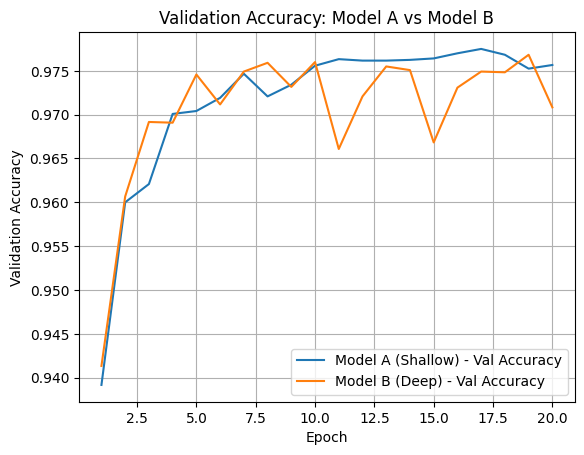

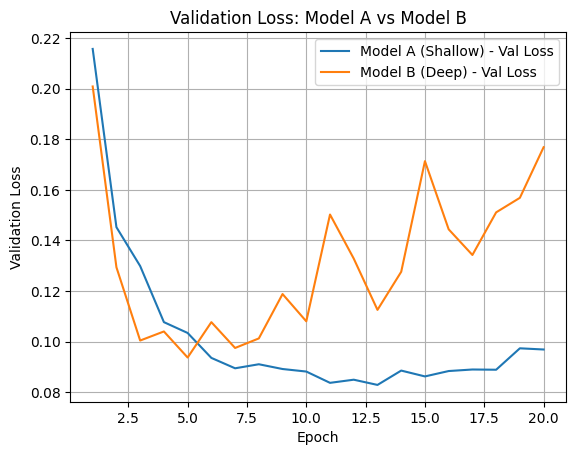

In [6]:
# 4/ The Output
epochs_range = range(1, EPOCHS + 1)

# Plot 1: Validation Accuracy
plt.figure()
plt.plot(epochs_range, history_a.history["val_accuracy"], label="Model A (Shallow) - Val Accuracy")
plt.plot(epochs_range, history_b.history["val_accuracy"], label="Model B (Deep) - Val Accuracy")
plt.title("Validation Accuracy: Model A vs Model B")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Validation Loss
plt.figure()
plt.plot(epochs_range, history_a.history["val_loss"], label="Model A (Shallow) - Val Loss")
plt.plot(epochs_range, history_b.history["val_loss"], label="Model B (Deep) - Val Loss")
plt.title("Validation Loss: Model A vs Model B")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()